# Libraries

In [1]:
# @title Libraries
# Работа с массивами
import numpy as np

# Отрисовка графиков
import matplotlib.pyplot as plt
plt.style.use('ggplot')

In [2]:
# Создание модельного временного ряда
test_series = [
    5.6, 4.7, 5.2, 9.1,
    7.1, 5.1, 6.1, 9.2,
    8.2, 5.6, 6.4, 9.5,
    9.1, 6.7, 7.5, 9.9
    ]

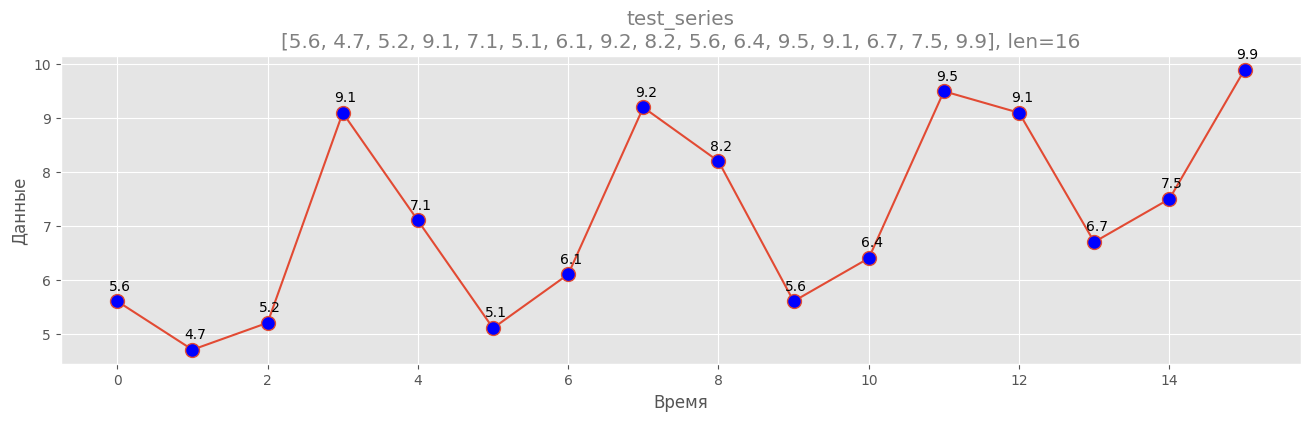

In [3]:
# @title Выведем временной ряд на графике:
plt.figure(figsize=(16,4))
plt.plot(test_series, marker='.', markersize=20, markerfacecolor='blue')
plt.xlabel('Время')
plt.ylabel('Данные')
plt.title(f'test_series\n{test_series}, len={len(test_series)}', color='gray')

# Добавляем подписи к точкам
for i, value in enumerate(test_series):
    plt.annotate(text=str(value), xy=(i, value), xytext=(2, 6), textcoords='offset points', ha='center', va='bottom')


plt.show()

# Коэффициент автокорреляции Пирсона

автокорреляция – это то, насколько два графика похожи друг на друга. Формула коэффициента написана ниже

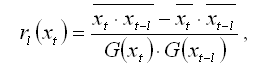

Создадим две переменные:
- x – базовый (текущий) временной ряд;
- y – базовый временной ряд, но смещенный на 1 шаг вправо.

In [4]:
# Исходный временной ряд
x = test_series
# Получение смещенного на один шаг временного ряда
y = [0.] + test_series[:-1]

print('Исходный: ', x)
print('Со свигом:', y)

Исходный:  [5.6, 4.7, 5.2, 9.1, 7.1, 5.1, 6.1, 9.2, 8.2, 5.6, 6.4, 9.5, 9.1, 6.7, 7.5, 9.9]
Со свигом: [0.0, 5.6, 4.7, 5.2, 9.1, 7.1, 5.1, 6.1, 9.2, 8.2, 5.6, 6.4, 9.5, 9.1, 6.7, 7.5]


In [5]:
# Получение общей части обоих рядов удалением нулевого элемента исходного ряда и последнего элемента смещенного
x_np = np.array(x[1:])
y_np = np.array(y[1:])

print(x_np)
print(y_np)

[4.7 5.2 9.1 7.1 5.1 6.1 9.2 8.2 5.6 6.4 9.5 9.1 6.7 7.5 9.9]
[5.6 4.7 5.2 9.1 7.1 5.1 6.1 9.2 8.2 5.6 6.4 9.5 9.1 6.7 7.5]


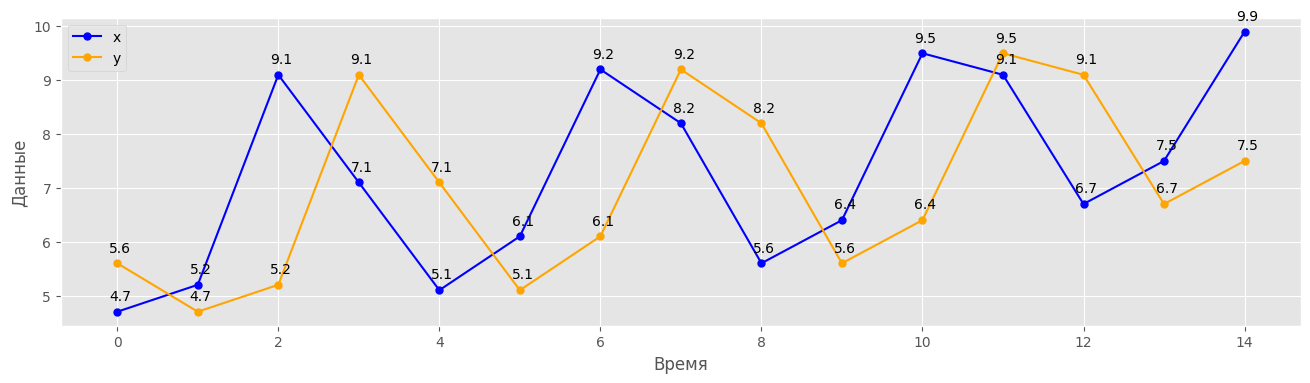

In [6]:
# @title # Отрисуем оба временных ряда на графике
# Рисование совместного графика исходного и смещенного временных рядов

def drawing_time_series(x, y):
  plt.figure(figsize=(16,4))
  plt.plot(x, marker='.', markersize=10, label='x', color='blue')
  plt.plot(y, marker='.', markersize=10, label='y', color='orange')
  plt.xlabel('Время')
  plt.ylabel('Данные')
  plt.legend()

  # Добавляем подписи к точкам на первом графике (x)
  for i, value in enumerate(x):
      plt.annotate(text=str(value), xy=(i, value), xytext=(2, 6), textcoords='offset points', ha='center', va='bottom')

  # Добавляем подписи к точкам на втором графике (y)
  for i, value in enumerate(y):
      plt.annotate(text=str(value), xy=(i, value), xytext=(2, 6), textcoords='offset points', ha='center', va='bottom')

  plt.show()

drawing_time_series(x_np, y_np)

In [7]:
# @title Расчет коэффициента автокорреляции Пирсона вручную

m12 = (x_np * y_np).mean()          # Мат. ожидание от произведения двух временных рядов
m1 = x_np.mean()                        # Мат. ожидание исходного временного ряда
m2 = y_np.mean()                      # Мат. ожидание смещенного временного ряда
s1 = x_np.std()                         # Среднеквадратическое отклонение (СКО) исходного временного ряда
s2 = y_np.std()                       # СКО смещенного временного ряда
k = (m12 - m1*m2) / (s1 * s2)             # Коэффициент автокорреляции исходного ряда при смещении на один шаг

print('Мат. ожидание произведения двух рядов: {:.2f}'.format(m12))
print('Мат. ожидание первого ряда: {:.2f}'.format(m1))
print('Мат. ожидание второго ряда: {:.2f}'.format(m2))
print('СКО первого ряда: {:.2f}'.format(s1))
print('СКО второго ряда: {:.2f}'.format(s2))
print('Коэффициент автокорреляции при смещении на 1 шаг: {:.4f}'.format(k))

Мат. ожидание произведения двух рядов: 51.74
Мат. ожидание первого ряда: 7.29
Мат. ожидание второго ряда: 7.01
СКО первого ряда: 1.71
СКО второго ряда: 1.61
Коэффициент автокорреляции при смещении на 1 шаг: 0.2298


In [8]:
# Способ получить коэффициент автокорреляции встроенными средствами numpy
np.corrcoef(x_np, y_np)

array([[1.       , 0.2298064],
       [0.2298064, 1.       ]])

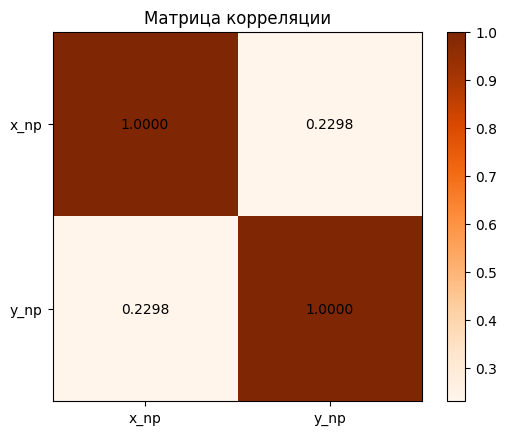

In [9]:
# @title corrcoef


plt.style.use('default')

# Ваша матрица корреляции
corr_matrix = np.array([[1.0, 0.2298064],
                        [0.2298064, 1.0]])

# Построение тепловой карты
plt.imshow(corr_matrix, cmap='Oranges')

# Добавление цветовой шкалы
plt.colorbar()

# Добавление аннотаций
for i in range(corr_matrix.shape[0]):
    for j in range(corr_matrix.shape[1]):
        plt.text(j, i, f'{corr_matrix[i, j]:.4f}',
                 ha='center', va='center', color='black')

# Настройка осей
plt.xticks(np.arange(corr_matrix.shape[1]), ['x_np', 'y_np'])
plt.yticks(np.arange(corr_matrix.shape[0]), ['x_np', 'y_np'])

# Название графика
plt.title('Матрица корреляции')

# Отображение графика
plt.show()


In [10]:
# @title Функция вычисления коэффициента автокорреляции

def get_corr_coef(data, # данные
                  step): #  шаг смещения >= 0

    '''Получение общих частей исходного и смещенного на step рядов,
    # затем вычисление матрицы коэффициентов и отбор коэффициента из нужного места матрицы'''

    return np.corrcoef(data[step:], data[:len(data) - step])[0, 1]

get_corr_coef(test_series, 1)

np.float64(0.22980639547693596)

 original: [5.6, 4.7, 5.2, 9.1, 7.1, 5.1, 6.1, 9.2, 8.2, 5.6, 6.4, 9.5, 9.1, 6.7, 7.5, 9.9] 16
 x: [4.7, 5.2, 9.1, 7.1, 5.1, 6.1, 9.2, 8.2, 5.6, 6.4, 9.5, 9.1, 6.7, 7.5, 9.9] 15
 y: [5.6, 4.7, 5.2, 9.1, 7.1, 5.1, 6.1, 9.2, 8.2, 5.6, 6.4, 9.5, 9.1, 6.7, 7.5] 15
Коэфицент корреляции: 0.2298


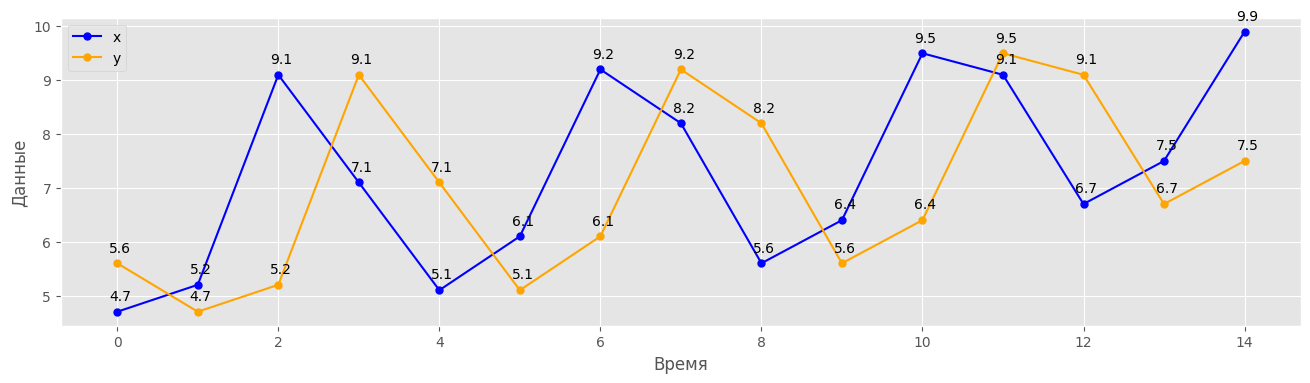

In [11]:
# @title Функция для сравнения последовательностей X и Y.
def sequence_comparison(data, step):
  plt.style.use('ggplot')
  x = data[step:]
  y = data[:len(data) - step]


  print('\033[92m original\033[0m:', data, len(data))
  print('='*91)

  print('\033[94m x\033[0m:', x, len(x))
  print('\033[91m y\033[0m:', y, len(y))
  print('='*91)

  print(f'\033[95mКоэфицент корреляции: {round(np.corrcoef(data[step:], data[:len(data) - step])[0, 1], 4)}\033[0m')
  drawing_time_series(x, y) # для отрисовки 2 графиков


sequence_comparison(test_series, 1)

In [12]:
print(len(test_series))

16


 original: [5.6, 4.7, 5.2, 9.1, 7.1, 5.1, 6.1, 9.2, 8.2, 5.6, 6.4, 9.5, 9.1, 6.7, 7.5, 9.9] 16
 x: [9.9] 1
 y: [5.6] 1
Коэфицент корреляции: nan


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2914: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


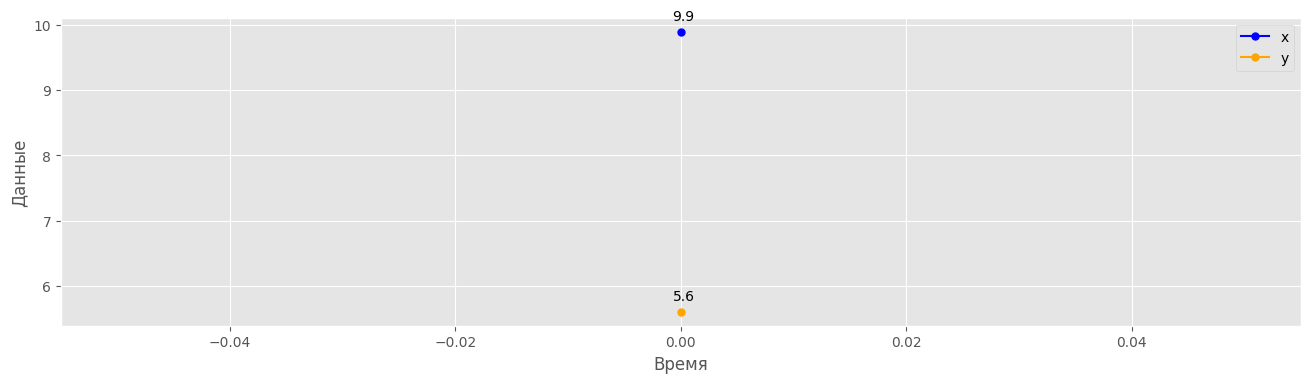

In [13]:
step = 15  # берем последнее значение по индексу

sequence_comparison(test_series, step)

 original: [5.6, 4.7, 5.2, 9.1, 7.1, 5.1, 6.1, 9.2, 8.2, 5.6, 6.4, 9.5, 9.1, 6.7, 7.5, 9.9] 16
 x: [7.5, 9.9] 2
 y: [5.6, 4.7] 2
Коэфицент корреляции: -1.0


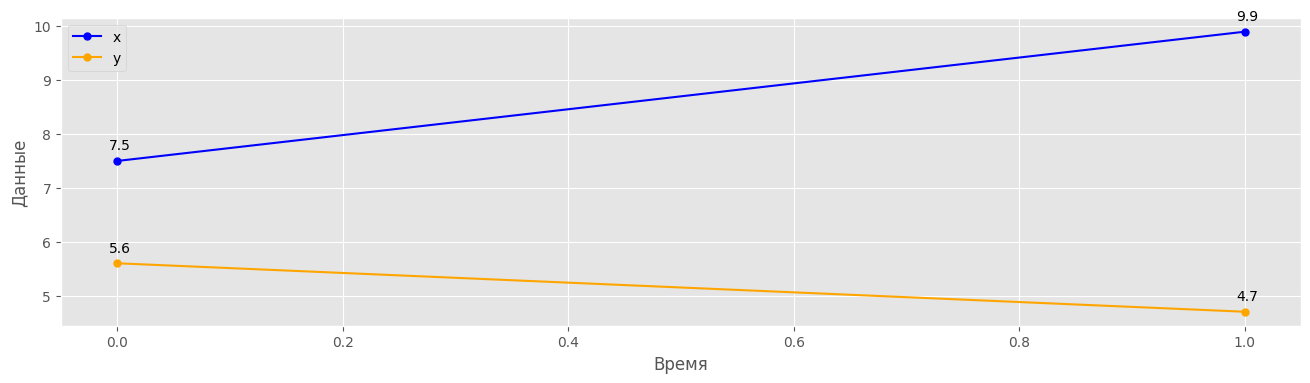

In [14]:
step = 14 # берём значение на 2 меньше

sequence_comparison(test_series, step)

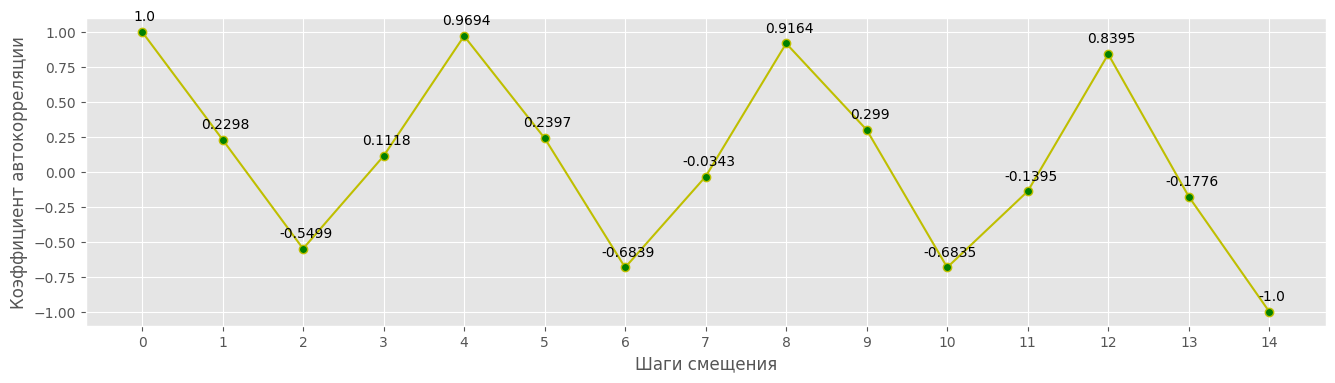

In [15]:
# @title Функция рисования графика коэффициентов автокорреляции данных на разных шагах смещения

def autocorr_graph(data, steps_max):
    plt.style.use('ggplot')

    # Задание последовательности шагов смещения от 0 до steps_max
    # и расчет коэффициентов автокорреляции для этих смещений
    steps = range(steps_max + 1)

    coefs = [get_corr_coef(data, step) for step in steps]

    # Рисование графика коэффициентов автокорреляции
    plt.figure(figsize=(16, 4))
    plt.plot(steps, coefs, marker='.', markersize=12, markerfacecolor='green', color='y')
    plt.xticks(steps)
    plt.xlabel('Шаги смещения')
    plt.ylabel('Коэффициент автокорреляции')

    coef_round = list(map(lambda x: round(x, 4), coefs))

    for i, value in enumerate(coef_round):
      plt.annotate(text=str(value), xy=(i, value), xytext=(2, 6), textcoords='offset points', ha='center', va='bottom')

    plt.show()


autocorr_graph(test_series, 14)

График начинается с 1, так как первый расчет сделан без смещения. То есть автокорреляция базового ряда самого к себе.

Вершины графика показывают, что если сместить график на 4, 8 или 12 шагов, то он останется практически таким же. Смещение на 3, 5, 7, 11, 13 показывает, что графики максимально различны. 2, 6, 10, 14 – графики противоположны:

 original: [5.6, 4.7, 5.2, 9.1, 7.1, 5.1, 6.1, 9.2, 8.2, 5.6, 6.4, 9.5, 9.1, 6.7, 7.5, 9.9] 16
 x: [6.1, 9.2, 8.2, 5.6, 6.4, 9.5, 9.1, 6.7, 7.5, 9.9] 10
 y: [5.6, 4.7, 5.2, 9.1, 7.1, 5.1, 6.1, 9.2, 8.2, 5.6] 10
Коэфицент корреляции: -0.6839


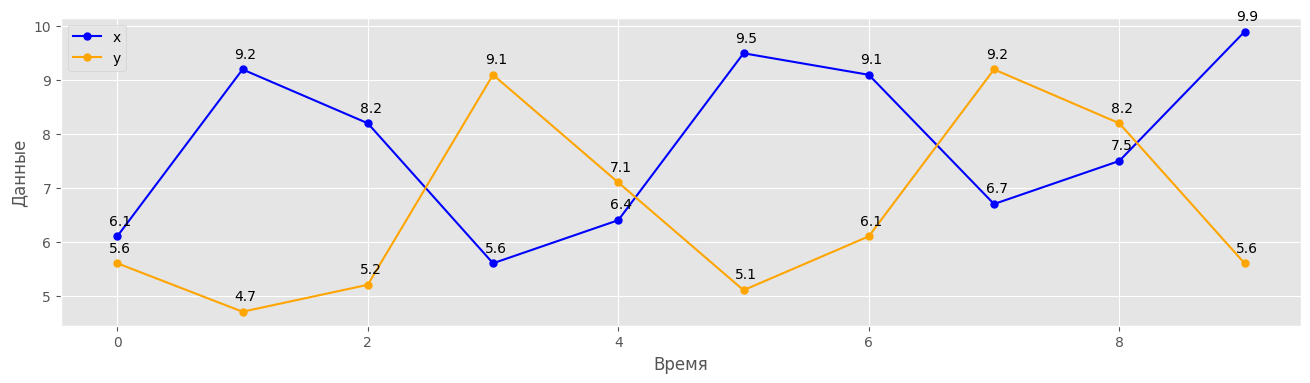

In [16]:
sequence_comparison(test_series, 6)

Опишем функцию, которая сместит график на нужное количество шагов и отрисует его:

Шаги смещения: 12
Коэф. автокорреляции: 0.8395


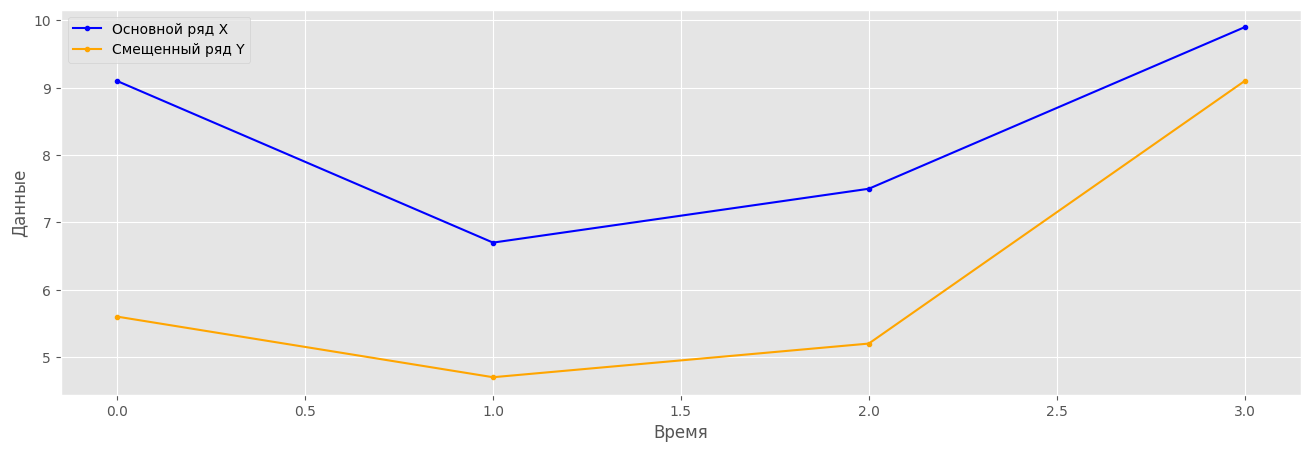

In [17]:
# @title Функция иллюстрации смещения на заданное число шагов

def show_skew(data, step):
    # Построение и вывод общих частей исходного и смещенного рядов
    x = data[step:]
    y = data[:len(data) - step]

    print(f'\033[92mШаги смещения:\033[0m {step}\n\033[95mКоэф. автокорреляции: \033[0m{get_corr_coef(data, step):.4f}')

    # Рисование совместного графика исходного и смещенного временных рядов
    plt.figure(figsize=(16, 5))
    plt.plot(x, marker='.', label='Основной ряд X', color='b')
    plt.plot(y, marker='.', label='Смещенный ряд Y', color='orange')
    plt.xlabel('Время')
    plt.ylabel('Данные')
    plt.legend()

    plt.show()


# Иллюстрация смещения
show_skew(test_series, 12)

# Влияние тренда
Отрисуем случайно созданный временной ряд из 30 значений:

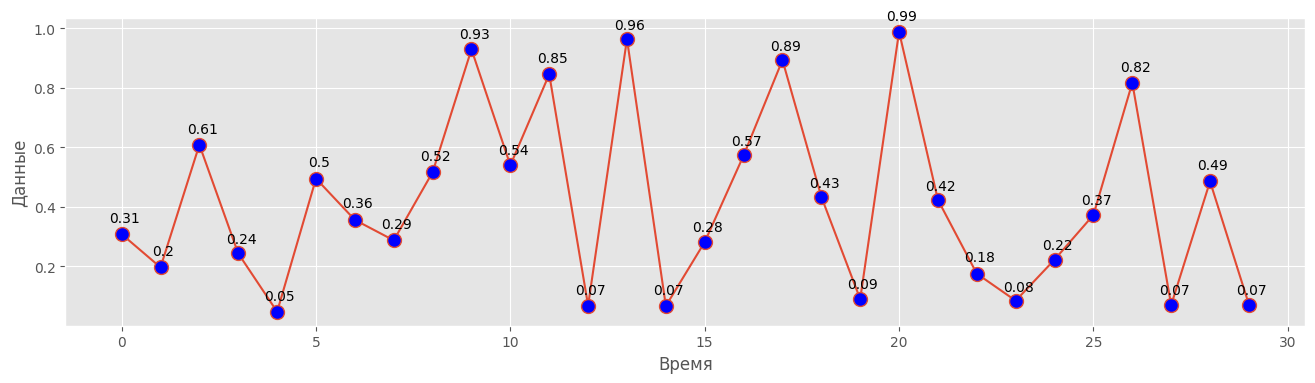

In [18]:
# В качестве модельного ряда используется несколько случайных значений
random_series = np.random.rand(30)
rand_series = map(lambda x: round(x, 2), random_series)

# Построение графика ряда
plt.figure(figsize=(16,4))
plt.plot(random_series, marker='.', markersize=20, markerfacecolor='blue')
plt.xlabel('Время')
plt.ylabel('Данные')

for i, value in enumerate(rand_series):
    plt.annotate(text=str(value), xy=(i, value), xytext=(2, 6), textcoords='offset points', ha='center', va='bottom')



plt.show()

Шаги смещения: 1
Коэф. автокорреляции: -0.2052


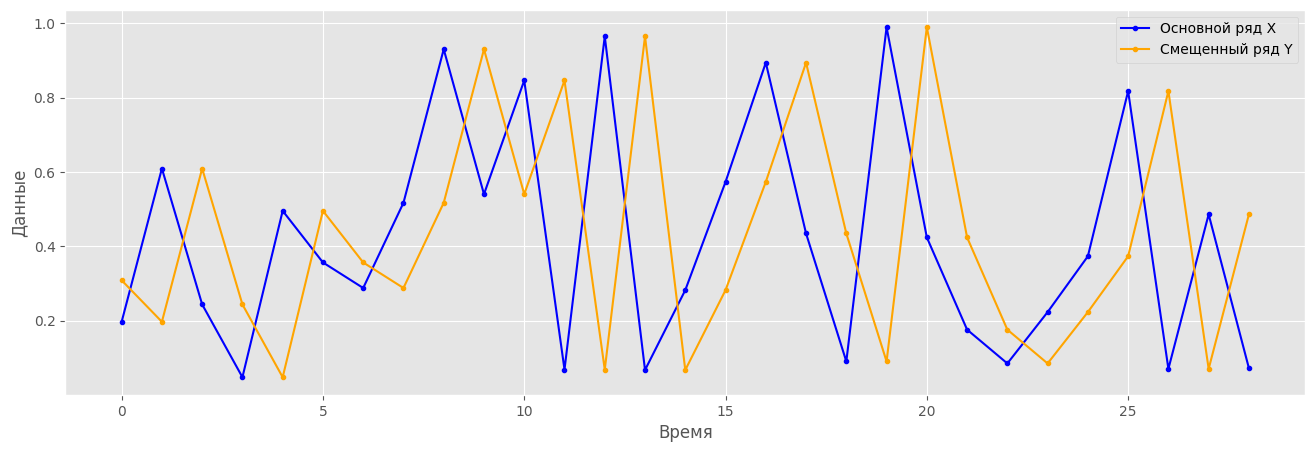

In [19]:
# Коэффициент автокорреляции при смещении на 1 шаг
show_skew(random_series, 1)

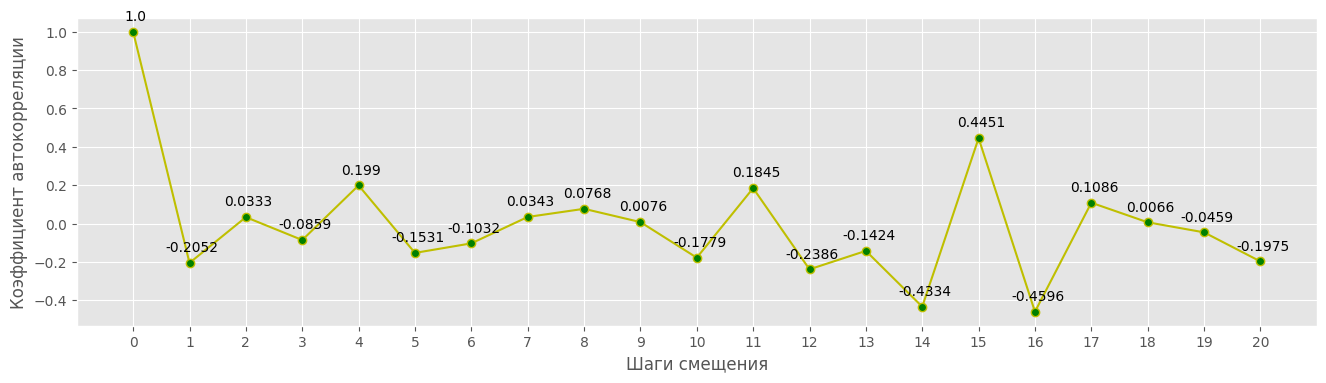

In [20]:
# График коэффициентов автокорреляции модельного ряда
autocorr_graph(random_series, 20)

Изменим базовый ряд, чтобы появился растущий тренд:

**np.linspace()** возвращает одномерный массив из указанного количества элементов, значения которых равномерно распределены внутри заданного интервала. Его параметры:
- start – число в начале последовательности.
- stop – число в конце последовательности, если `endpoint=True`. Если `endpoint=False`, то это число не включается в интервал. При этом изменяется значение шага между элементами последовательности.
- num – целое положительное число (не обязательный параметр). Определяет количество элементов последовательности. По умолчанию `num = 50`.
- endpoint – True или False (не обязательный параметр). Если `endpoint = True`, то значение stop включается в интервал и становится последним. В противном случае stop не входит в интервал. По умолчанию `endpoint = True`.

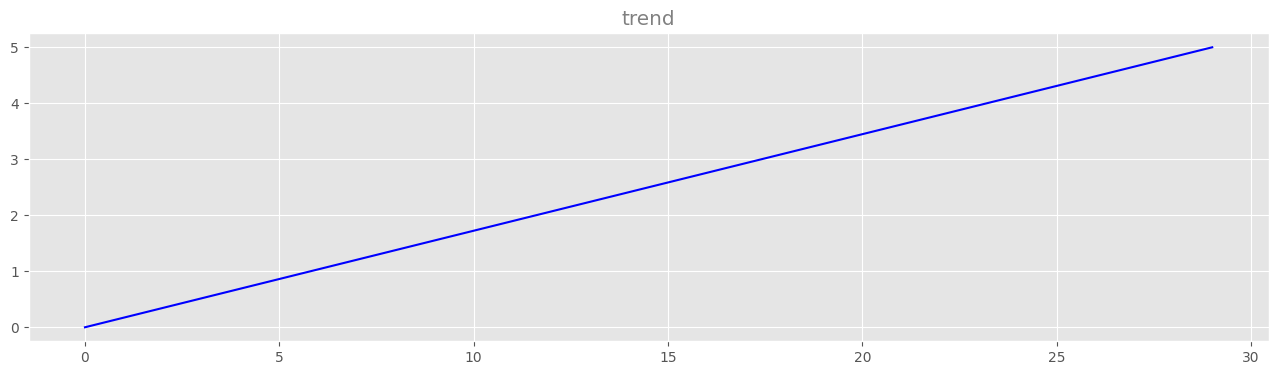

In [21]:
# Генерация шума в виде линейно возрастающего тренда
# Величина шума большая по сравнению с величиной элементов модельного ряда
trend = np.linspace(0., 5., random_series.shape[0])

plt.figure(figsize=(16,4))
plt.plot(trend, color='b')
plt.title('trend', color='gray')
plt.show()

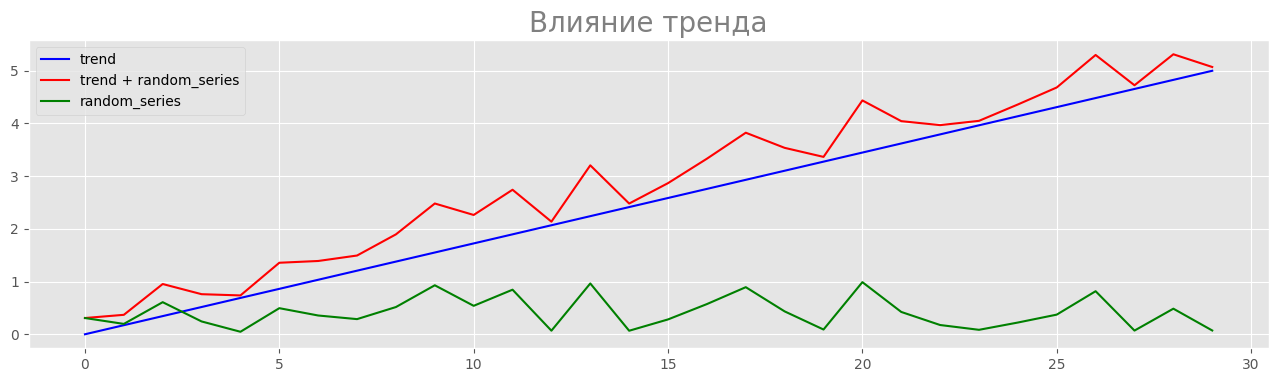

In [22]:
# Получение искаженного ряда сложением основного ряда и тренда (шума)
trended_series = random_series + trend

# Проверка результата
plt.figure(figsize=(16,4))
plt.plot(trend, label='trend', color='blue')
plt.plot(trended_series, label='trend + random_series', color='red')
plt.plot(random_series, label='random_series', color='green')
plt.title('Влияние тренда', fontsize=20, color='gray')
plt.legend()
plt.show()

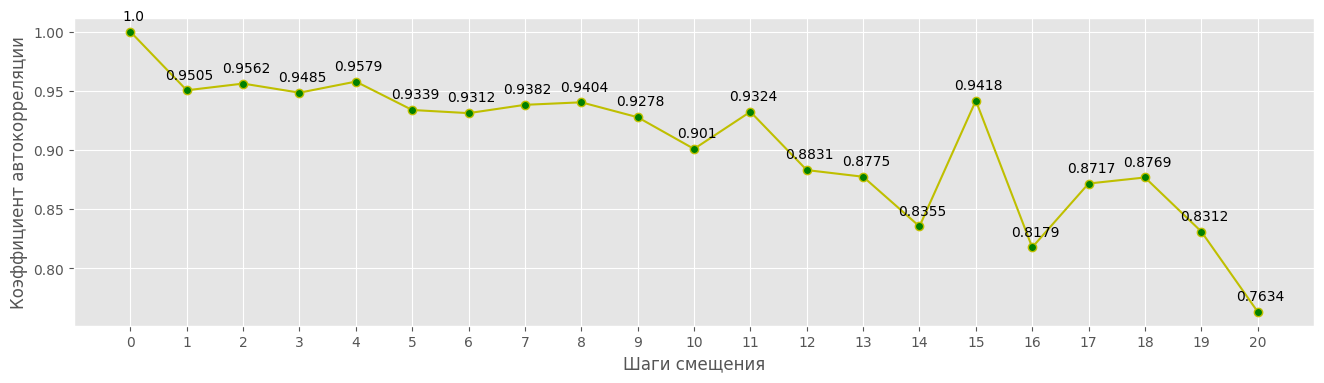

In [23]:
autocorr_graph(trended_series, 20)

Шаги смещения: 2
Коэф. автокорреляции: 0.9562


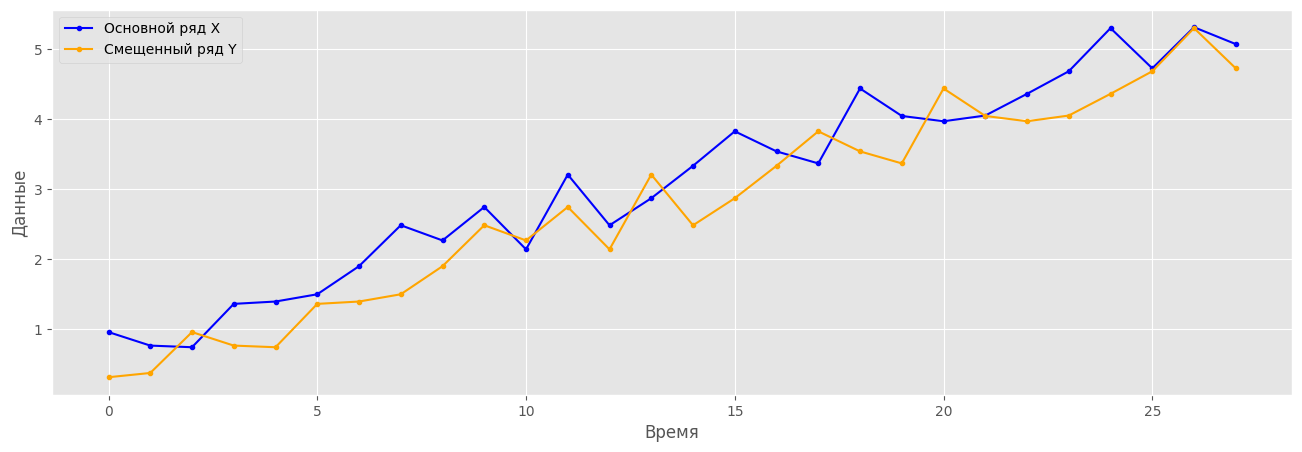

In [24]:
show_skew(trended_series,2)

Шаги смещения: 2
Коэф. автокорреляции: 0.0333


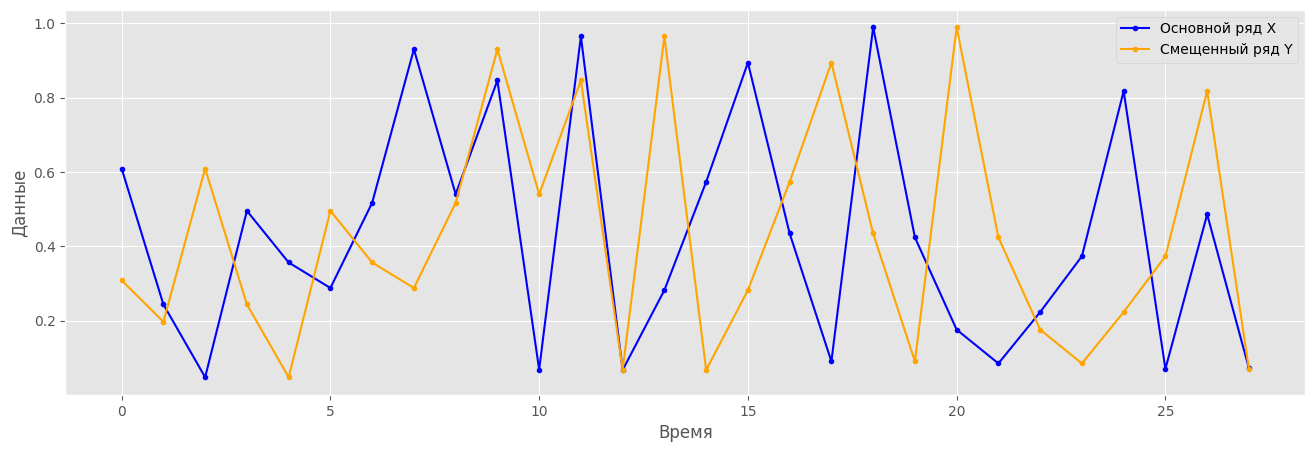

In [25]:
show_skew(random_series, 2)

Тренд отрицательно влияет на коэффициент автокорреляции. Посмотрим, как при помощи дифференцирования можно убрать его влияние на данные.

Дифференцирование данных – это вычитание текущего значения из следующего. Например, для графика

        [5, 7, 8, 3, 6, 2, 1]

результат дифференцирования – ряд:

         [2, 1, -5, 3, -4, -1]
         т.к. 7-5=2, 8-7=1, ..., 1-2=-1
         
Применим операцию к нашим данным:

# Метод избавления от влияния тренда: численное дифференцирование временных рядов

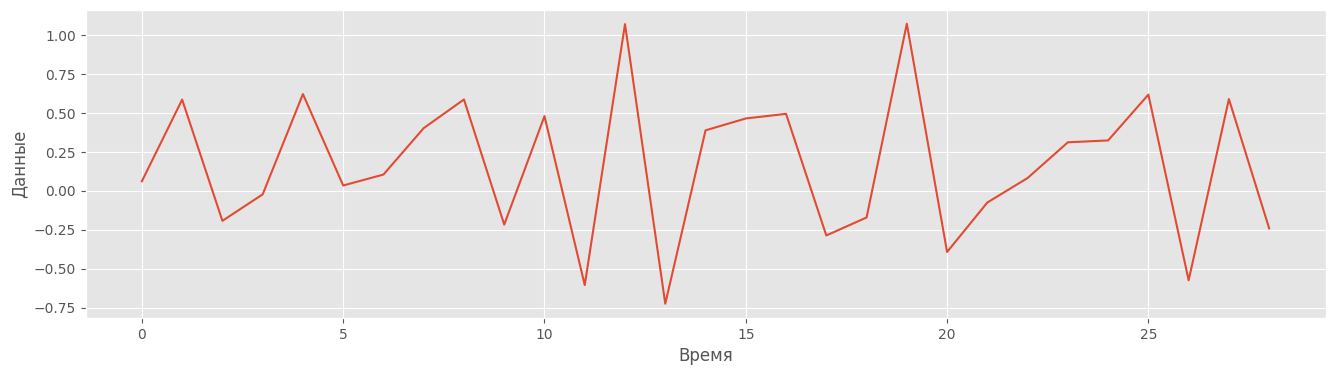

In [26]:
# Численное дифференцирование искаженного ряда
trended_series_diff = np.diff(trended_series)

# Построение графика полученного ряда
plt.figure(figsize=(16,4))
plt.plot(trended_series_diff)
plt.xlabel('Время')
plt.ylabel('Данные')
plt.show()

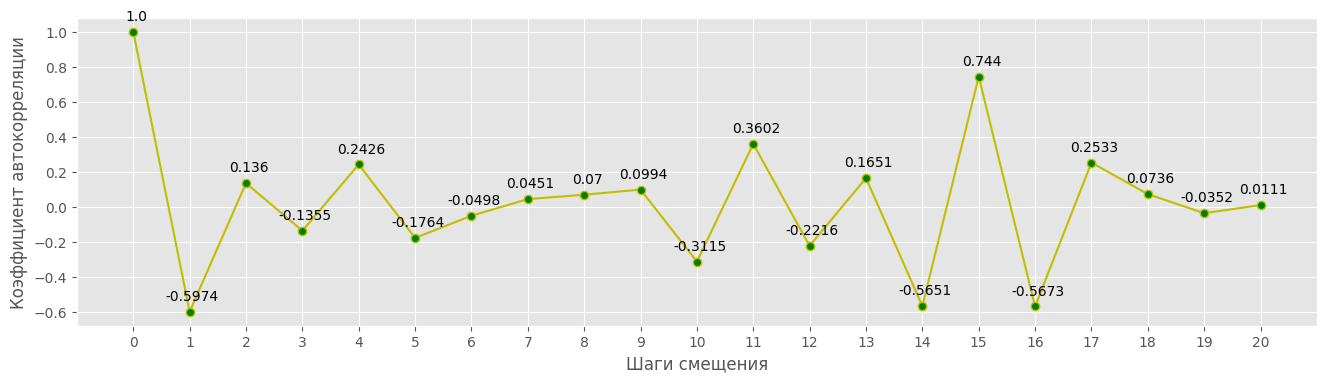

In [27]:
# График коэффициентов автокорреляции дифференцированного ряда
autocorr_graph(trended_series_diff, 20)

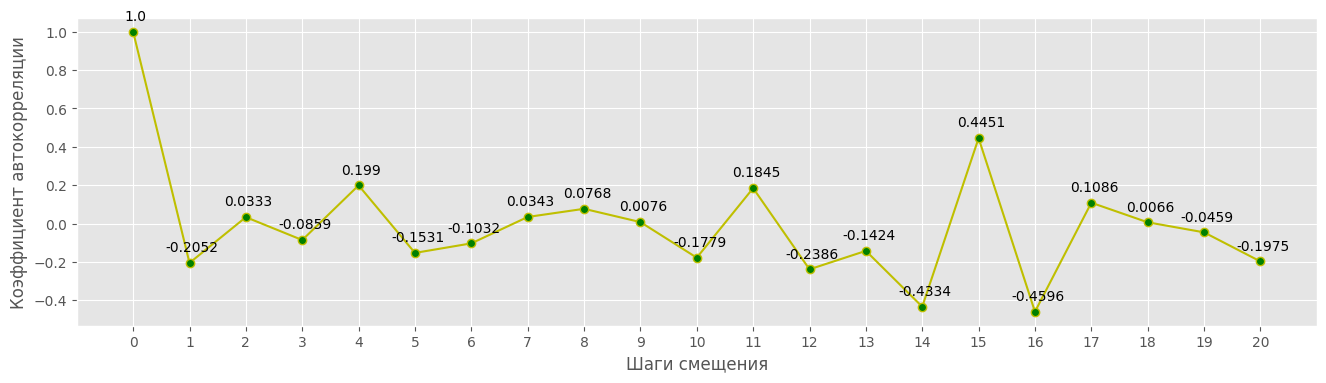

In [28]:
# Сравнение с графиком коэффициентов автокорреляции исходного ряда
autocorr_graph(random_series, 20)

---


**Вывод**: численное дифференцирование позволяет избавиться от влияния тренда на корреляционные показатели исходного ряда.

---



---
